<a href="https://www.kaggle.com/code/kaushikfreddyregalla/rq5-product-clustering?scriptVersionId=317676199" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# RQ5_Product_Clustering

In [1]:

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans

# -----------------------------------
# LOAD DATASET
# -----------------------------------

dataset_path = '/kaggle/input/datasets/kaushikfreddyregalla/nike-global-catalogue/NIKE_GLOBAL_CATALOGUE.csv'

df = pd.read_csv(dataset_path)

print("Dataset Loaded Successfully")
display(df.head())

# -----------------------------------
# BASIC CLEANING
# -----------------------------------

df.drop_duplicates(inplace=True)

# Fill categorical missing values
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill numerical missing values
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col] = df[col].fillna(df[col].mean())

# Create discount percentage
if 'price_local' in df.columns and 'sale_price_local' in df.columns:
    df['discount_pct'] = (
        (df['price_local'] - df['sale_price_local']) /
        df['price_local']
    ) * 100

# Replace inf values
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill remaining NaN
df.fillna(0, inplace=True)

# Encode categorical variables safely
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

print("Dataset Shape:", df.shape)


Dataset Loaded Successfully


,snapshot_date,country_code,product_name,model_number,currency,price_local,sale_price_local,gender_segment,size_label,category,...,canonical_url,image_url,gtin,stock_keeping_unit_id,catalog_sku_id,nike_size,localized_size,size_conversion_id,sport_tags,record_source
0,2026-03-19,CA,"A'One ""MVPs""",FZ8605,CAD,145.0,88.0,MEN|WOMEN,W 10 / M 8.5,FOOTWEAR,...,https://www.nike.com/ca/t/aone-mvps-aja-wilson...,https://secure-images.nike.com/is/image/DotCom...,0.0,1.005110e+09,f150b97d-f31a-3278-8f57-62afa808da04,10,W 10 / M 8.5,e3938ff5-38af-3583-9b33-8616d36ffb4c,Basketball,thread_exact
1,2026-03-19,CA,"A'One ""MVPs""",FZ8605,CAD,145.0,88.0,MEN|WOMEN,W 10.5 / M 9,FOOTWEAR,...,https://www.nike.com/ca/t/aone-mvps-aja-wilson...,https://secure-images.nike.com/is/image/DotCom...,0.0,1.005110e+09,51b27f9f-0aad-35e2-8ac3-3e0de39d424c,10.5,W 10.5 / M 9,5e74cea8-794f-3777-a2e4-fed0c4e23e54,Basketball,thread_exact
2,2026-03-19,CA,"A'One ""MVPs""",FZ8605,CAD,145.0,88.0,MEN|WOMEN,W 11 / M 9.5,FOOTWEAR,...,https://www.nike.com/ca/t/aone-mvps-aja-wilson...,https://secure-images.nike.com/is/image/DotCom...,0.0,1.005110e+09,a3852f4f-4adb-3058-8e1a-37595e23a08f,11,W 11 / M 9.5,8bad6a46-de5b-3ee6-9ae5-6ebacd93646b,Basketball,thread_exact
3,2026-03-19,CA,"A'One ""MVPs""",FZ8605,CAD,145.0,88.0,MEN|WOMEN,W 11.5 / M 10,FOOTWEAR,...,https://www.nike.com/ca/t/aone-mvps-aja-wilson...,https://secure-images.nike.com/is/image/DotCom...,0.0,1.005110e+09,97442809-182b-3883-97f1-4b178e217f93,11.5,W 11.5 / M 10,6fdb2281-e298-3475-9e6a-dd374fb39645,Basketball,thread_exact
4,2026-03-19,CA,"A'One ""MVPs""",FZ8605,CAD,145.0,88.0,MEN|WOMEN,W 12 / M 10.5,FOOTWEAR,...,https://www.nike.com/ca/t/aone-mvps-aja-wilson...,https://secure-images.nike.com/is/image/DotCom...,0.0,1.005110e+09,8d32791a-65e1-3f47-9005-bde7b1158754,12,W 12 / M 10.5,dab24b05-d417-3b5e-9174-02d427dbd621,Basketball,thread_exact


Dataset Shape: (103679, 35)


Clustering Features:
   price_local  discount_pct
0        145.0     39.310345
1        145.0     39.310345
2        145.0     39.310345
3        145.0     39.310345
4        145.0     39.310345
\nRQ5 TABLE OUTPUT:\n


,Cluster,price_local,discount_pct
0,0,40.334702,-128.039920
1,1,81.075758,-17.426724
2,2,180.945410,45.576404


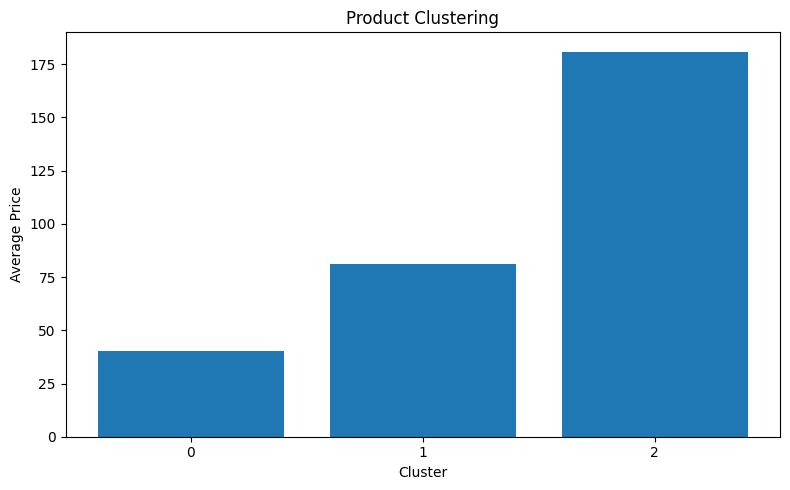

\nFiles Saved Successfully:
1. RQ5_table.csv
2. RQ5_figure.pdf


In [2]:

# -----------------------------------
# RQ5: PRODUCT CLUSTERING
# -----------------------------------

# Keep only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Required features
features = []

if 'price_local' in numeric_df.columns:
    features.append('price_local')

if 'discount_pct' in numeric_df.columns:
    features.append('discount_pct')

# If features missing, use first numeric columns
if len(features) < 2:
    features = numeric_df.columns[:2].tolist()

cluster_df = numeric_df[features].copy()

# Final Cleaning
cluster_df = cluster_df.replace([np.inf, -np.inf], 0)
cluster_df = cluster_df.fillna(0)

print("Clustering Features:")
print(cluster_df.head())

# -----------------------------------
# STANDARDIZATION
# -----------------------------------

scaler = StandardScaler()

scaled = scaler.fit_transform(cluster_df)

# -----------------------------------
# KMEANS CLUSTERING
# -----------------------------------

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_df['Cluster'] = kmeans.fit_predict(scaled)

# -----------------------------------
# TABLE OUTPUT
# -----------------------------------

summary = cluster_df.groupby('Cluster').mean().reset_index()

summary.to_csv('RQ5_table.csv', index=False)

print("\\nRQ5 TABLE OUTPUT:\\n")

display(summary)

# -----------------------------------
# FIGURE OUTPUT
# -----------------------------------

plt.figure(figsize=(8,5))

plt.bar(
    summary['Cluster'].astype(str),
    summary[features[0]]
)

plt.xlabel('Cluster')
plt.ylabel('Average Price')

plt.title('Product Clustering')

plt.tight_layout()

# Save Figure
plt.savefig('RQ5_figure.pdf')

plt.show()

print("\\nFiles Saved Successfully:")
print("1. RQ5_table.csv")
print("2. RQ5_figure.pdf")
